In [1]:
# ===========================
# CELL 1: MASTER INSTALLATION
# ===========================
import os
import sys
import importlib

print("⏳ Step 1/8: Pinning Colab's required Pandas version FIRST...")
# Google Colab specifies pandas==2.2.2. Force it.
!pip install pandas==2.2.2 -q
print("✅ Colab's Pandas version pinned.")

print("\n⏳ Step 2/8: Verifying initial Numpy version...")
try:
    import numpy as np_check
    print(f"✅ Numpy version after pinning Pandas: {np_check.__version__}")
except ImportError:
    print("⚠️ Numpy not found yet, installing base essentials...")
    !pip install numpy cython wheel setuptools --upgrade -q

print("\n⏳ Step 3/8: Installing Build Tools...")
!pip install cython wheel setuptools --upgrade -q
print("✅ Build tools updated.")

# --- ** Install TA-Lib (C Library) ** ---
print("\n⏳ Step 4/8: Installing TA-Lib C library...")
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz -q
!tar -xzf ta-lib-0.4.0-src.tar.gz
%cd ta-lib/
!./configure --prefix=/usr -q
!make -s # Use -s for silent build
!make install -s
%cd ..
!rm -r ta-lib* # Clean up source files
print("✅ TA-Lib C library installed.")
# -----------------------------------------------------------

# --- Install Python TA-Lib Wrapper ---
print("\n⏳ Step 5/8: Installing TA-Lib Python wrapper...")
!pip install TA-Lib -q
print("✅ TA-Lib Python wrapper installed.")
# ------------------------------------

# --- Install other dependencies ---
print("\n⏳ Step 6/8: Installing other dependencies (Gymnasium, SB3, ta, etc.)...")
# *** ADDED 'ta' library here ***
!pip install gymnasium stable-baselines3[extra] gym==0.26.2 'shimmy>=1.0' yfinance exchange-calendars wrds websockets stockstats pyportfolioopt ta --upgrade -q
print("✅ Base & other FinRL dependencies installed (excluding Pyfolio, including ta).")
# ------------------------------------

# --- Manually Clone FinRL-Meta Repository ---
print("\n⏳ Step 7/8: Cloning FinRL-Meta repository from GitHub...")
!rm -rf FinRL-Meta/
!git clone https://github.com/AI4Finance-Foundation/FinRL-Meta.git -q

# --- Add FinRL-Meta to Python Path ---
print("\n⏳ Step 8/8: Adding FinRL-Meta to system path...")
finrl_meta_path = os.path.abspath('FinRL-Meta')
if finrl_meta_path not in sys.path:
    sys.path.append(finrl_meta_path)
    print(f"✅ Added '{finrl_meta_path}' to system path.")
else:
    print(f"FinRL-Meta path already in system path.")
# -------------------------------------------

print("\n\n✅✅✅ Installation Cell (Strategy 8 - NO Pyfolio, ADD ta) Complete. ✅✅✅")
print("⚠️ Pyfolio was SKIPPED. Standard FinRL-Meta backtesting scripts WILL FAIL.")
print("   You MUST implement your own performance evaluation after training.")

# --- Final Check: Import key libraries ---
print("\nVerifying key imports...")
try:
    import numpy
    import pandas
    import ta # Now checking the 'ta' library
    import gymnasium
    import stable_baselines3
    import meta # *** CORRECTED IMPORT HERE ***
    print("✅ Key libraries seem to import correctly.")
except Exception as e:
    print(f"🔥ERROR: A key library failed to import: {e}")

⏳ Step 1/8: Pinning Colab's required Pandas version FIRST...
✅ Colab's Pandas version pinned.

⏳ Step 2/8: Verifying initial Numpy version...
✅ Numpy version after pinning Pandas: 2.0.2

⏳ Step 3/8: Installing Build Tools...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
✅ Build tools updated.

⏳ Step 4/8: Installing TA-Lib C library...
/content/ta-lib
appending configuration tag "CXX" to libtool
appending configuration tag "F77" to libtool
Making all in src
Making all in ta_abstract
mkdir .libs
 gcc -DHAVE_CONFIG_H -I. -I../../include -I../ta_common/ -Iframes/ -g -O2 -MT libta_abstract_la-ta_group_idx.lo -MD -MP -MF .deps/libta_abstract_la-ta_group_

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# ==================================
# CELL 2: MOUNT DRIVE & DEFINE PATHS
# ==================================
from google.colab import drive
import os

print("\nMounting Google Drive...")
try:
    # Use standard mount. If '/content/drive' is dirty,
    # this will either handle it or fail cleanly.
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")

    # Define all project paths
    # --- IMPORTANT: Make sure this base path exists in your Google Drive ---
    BASE_PROJECT_PATH = r"/content/drive/MyDrive/Nifty50_RL_Project"
    PROCESSED_DIR = os.path.join(BASE_PROJECT_PATH, "finance_data", "processed")
    MODELS_DIR = os.path.join(BASE_PROJECT_PATH, "models")
    LOG_DIR = os.path.join(BASE_PROJECT_PATH, "logs")

    # Create folders in your Drive if they don't exist
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    os.makedirs(MODELS_DIR, exist_ok=True)
    os.makedirs(LOG_DIR, exist_ok=True)

    print(f"\nAll paths are set. Base project path: {BASE_PROJECT_PATH}")
    print(f"Processed data dir: {PROCESSED_DIR}")
    print(f"Models will save to: {MODELS_DIR}")
    print(f"Logs will save to: {LOG_DIR}")

except Exception as e:
    print(f"Error mounting drive or creating directories: {e}")
    print("Please check your Drive permissions and ensure the BASE_PROJECT_PATH exists.")
    raise # Stop if drive mounting or path setup fails

print("\n✅ Setup cell finished.")


Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.

All paths are set. Base project path: /content/drive/MyDrive/Nifty50_RL_Project
Processed data dir: /content/drive/MyDrive/Nifty50_RL_Project/finance_data/processed
Models will save to: /content/drive/MyDrive/Nifty50_RL_Project/models
Logs will save to: /content/drive/MyDrive/Nifty50_RL_Project/logs

✅ Setup cell finished.


In [ ]:
# =====================================
# CELL 3: DATA FILTERING AND PROCESSING
# =====================================
print("Starting: Loading Clean, Adding ALL Features (incl. ATR), Filtering, Splitting...")

import pandas as pd
import numpy as np
import os
from stockstats import StockDataFrame as Sdf
import traceback
from ta.volatility import AverageTrueRange

clean_filepath = os.path.join(PROCESSED_DIR, "_NIFTY50_CLEAN_LONG_FORMAT.csv")

# =======================
# STEP 1: LOAD CLEAN DATA
# =======================
print(f"\nLoading clean data from: {clean_filepath}")
try:
    df_clean = pd.read_csv(clean_filepath)
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    df_clean = df_clean.rename(columns={'date': 'time'})
    df_clean = df_clean.sort_values(['time', 'tic']).reset_index(drop=True)
    print(f"Clean data loaded. Shape: {df_clean.shape}")
except FileNotFoundError:
    print(f"Error: Clean file not found at {clean_filepath}")
    raise
except Exception as e:
    print(f"An error occurred loading clean data: {e}")
    raise

# =========================================
# STEP 2: ADD STANDARD TECHNICAL INDICATORS
# =========================================
print("\nAdding standard technical indicators (MACD, RSI, BBs, SMAs, VO, ATR)...")
try:
    stock_df_orig = df_clean.copy()
    unique_tickers_list = stock_df_orig['tic'].unique()
    all_indicators_list = []
    total_tickers = len(unique_tickers_list)
    required_cols_for_stockstats = ['time', 'open', 'high', 'low', 'close', 'volume']

    for i, ticker in enumerate(unique_tickers_list):
        temp_df_ticker = stock_df_orig[stock_df_orig.tic == ticker][required_cols_for_stockstats].copy()
        if len(temp_df_ticker) < 200:
            print(f"Warning: Insufficient data for {ticker} (< 200 rows). Skipping.")
            continue

        temp_df_ticker = temp_df_ticker.reset_index()
        temp_df_ticker_sdf_input = temp_df_ticker.rename(columns={'time':'date'}).copy()
        temp_sdf = Sdf.retype(temp_df_ticker_sdf_input)

        temp_sdf['macd']
        temp_sdf['rsi_14']
        temp_sdf['boll']
        temp_sdf['close_20_sma']
        temp_sdf['close_50_sma']
        temp_sdf['close_100_sma']
        temp_sdf['close_200_sma']
        temp_sdf['volume_12_ema']
        temp_sdf['volume_26_ema']
        temp_sdf['vo'] = temp_sdf['volume_12_ema'] - temp_sdf['volume_26_ema']

        atr_calc = AverageTrueRange(
            high=temp_df_ticker["high"], low=temp_df_ticker["low"],
            close=temp_df_ticker["close"], window=14
        )
        temp_df_ticker["atr"] = atr_calc.average_true_range()

        indicator_cols = {
            'macd': 'macd', 'rsi_14': 'rsi', 'boll_ub': 'boll_ub', 'boll_lb': 'boll_lb',
            'close_20_sma': 'sma_20', 'close_50_sma': 'sma_50', 'close_100_sma': 'sma_100',
            'close_200_sma': 'sma_200', 'vo': 'vo'
        }
        cols_to_keep = ['index'] + list(indicator_cols.keys())
        temp_indicators = temp_sdf[[col for col in cols_to_keep if col in temp_sdf.columns]].copy()
        temp_indicators = temp_indicators.rename(columns=indicator_cols)

        temp_df_merged = pd.merge(temp_df_ticker, temp_indicators, on='index', how='left')
        temp_df_merged['tic'] = ticker
        temp_df_merged = temp_df_merged.drop(columns=['index'])
        all_indicators_list.append(temp_df_merged)

    if not all_indicators_list:
        raise ValueError("No tickers had sufficient data for indicator calculation.")
    df_with_indicators = pd.concat(all_indicators_list, ignore_index=True)
    print("All standard indicators added and merged.")

except Exception as e:
    print(f"Error adding standard indicators: {e}")
    traceback.print_exc()
    raise

# ========================
# STEP 2.1: FILTER BY DATE
# ========================
START_DATE_FILTER = "2010-01-01"
print(f"\nFiltering all data to start after {START_DATE_FILTER}...")
df_with_indicators = df_with_indicators[df_with_indicators['time'] >= START_DATE_FILTER].copy()
if df_with_indicators.empty:
    raise ValueError(f"No data remaining after filtering for start date {START_DATE_FILTER}.")
print(f"Data trimmed. New shape: {df_with_indicators.shape}, New start date: {df_with_indicators['time'].min()}")
# =======================================

# ==============================
# STEP 2.2: Clean remaining NaNs
# ==============================
indicator_output_cols = ['macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr']
numeric_cols = df_with_indicators.select_dtypes(include=np.number).columns.tolist()
initial_rows = len(df_with_indicators)
df_with_indicators[numeric_cols] = df_with_indicators[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"\nReplaced inf values in numeric columns.")
columns_to_check_for_nan = ['time', 'open', 'high', 'low', 'close', 'volume', 'tic'] + indicator_output_cols
df_with_indicators.dropna(subset=[col for col in columns_to_check_for_nan if col in df_with_indicators.columns], inplace=True)
rows_dropped = initial_rows - len(df_with_indicators)
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} rows due to remaining NaN values.")
else:
    print("No rows dropped due to NaN values.")
if df_with_indicators.empty:
    raise ValueError("DataFrame is empty after dropping remaining NaNs.")
# =======================================


# =======================
# STEP 3:BALANCED DATASET
# =======================
print("\nVerifying data consistency and building a balanced dataset...")

# 1. Get day counts for all remaining tickers
ticker_day_counts = df_with_indicators.groupby('tic')['time'].nunique()
max_days = ticker_day_counts.max()
print(f"Max days found for any single ticker: {max_days}")

# 2. Find tickers that have *almost* all the data (e.g., > 99% of max_days)
# This keeps most stocks, dropping any with significant data gaps.
min_days_required = max_days * 0.99
complete_tickers_list = ticker_day_counts[ticker_day_counts >= min_days_required].index.tolist()
print(f"Found {len(complete_tickers_list)} tickers with >99% data (>= {min_days_required} days).")

if len(complete_tickers_list) < 2:
    raise ValueError(f"Only found {len(complete_tickers_list)} tickers with >99% data. Cannot create a portfolio. Check data source or lower the 99% threshold.")

# 3. Find the set of dates that are COMMON to ALL these tickers
# We do this by pivoting and dropping NaNs
df_filtered_tickers = df_with_indicators[df_with_indicators['tic'].isin(complete_tickers_list)]
df_pivot = df_filtered_tickers.pivot(index='time', columns='tic', values='close')

# Drop any DAY (row) that is missing even one stock
df_pivot_balanced = df_pivot.dropna(axis=0) # axis=0 drops rows (dates)
common_dates = df_pivot_balanced.index
print(f"Found {len(common_dates)} trading days common to all {len(complete_tickers_list)} tickers.")

# 4. Filter the original DataFrame to ONLY these stocks and ONLY these common dates
stock_tickers = sorted(complete_tickers_list) # Final list of stocks
df_final_processed = df_with_indicators[
    (df_with_indicators['tic'].isin(stock_tickers)) &
    (df_with_indicators['time'].isin(common_dates))
].copy()

print(f"✅✅✅ Final number of tickers for environment: {len(stock_tickers)} ✅✅✅")
print(f"   Tickers: {stock_tickers}")
print(f"   Total days for all tickers: {len(common_dates)}")
# =======================================


# ============================
# STEP 4: CALCULATE TURBULENCE
# ============================
print("\nCalculating Turbulence Index manually...")
def calculate_turbulence(df, window=252):
    df_copy = df.sort_values(['time', 'tic']).copy()
    unique_tics = sorted(df_copy['tic'].unique())
    num_tickers = len(unique_tics)
    if num_tickers == 0:
        df_copy['turbulence'] = 0.0
        return df_copy
    try:
        df_price_pivot = df_copy.pivot(index="time", columns="tic", values="close")
    except ValueError as e:
        print(f"Error pivoting data for turbulence: {e}.")
        raise
    df_returns_pivot = df_price_pivot.pct_change(fill_method=None)
    effective_window = min(window, len(df_returns_pivot) - 1)
    if effective_window < 2:
        print(f"Warning: Not enough data for turbulence calculation. Returning 0.")
        df_copy['turbulence'] = 0.0
        return df_copy
    print(f"Using turbulence window: {effective_window}")
    rolling_mean = df_returns_pivot.rolling(window=effective_window, min_periods=effective_window).mean()
    turbulence_index = []
    dates_with_turbulence = df_returns_pivot.index[effective_window:]
    print(f"Calculating turbulence for {len(dates_with_turbulence)} dates...")
    for date in dates_with_turbulence:
        current_returns = df_returns_pivot.loc[date].values
        current_mean = rolling_mean.loc[date].values
        window_start_idx = df_returns_pivot.index.get_loc(date) - effective_window + 1
        window_data = df_returns_pivot.iloc[window_start_idx : window_start_idx + effective_window]

        # Now that data is balanced, we don't need to dropna inside the loop
        current_cov = window_data.cov().values
        diff = current_returns - current_mean

        if np.isnan(diff).any():
            diff = np.nan_to_num(diff, nan=0.0)
        try:
            current_cov = np.nan_to_num(current_cov, nan=0.0, posinf=1e5, neginf=-1e5)
            current_cov += np.identity(current_cov.shape[0]) * 1e-8
            inv_cov = np.linalg.pinv(current_cov)
            turbulence = diff.dot(inv_cov).dot(diff.T)
            turbulence = turbulence / max(1, num_tickers) # Use num_tickers
            if turbulence < 0: turbulence = 0.0
        except (np.linalg.LinAlgError, IndexError, ValueError) as e:
            turbulence = np.nan
        turbulence_index.append(turbulence)

    turbulence_df = pd.DataFrame({'time': dates_with_turbulence, 'turbulence': turbulence_index})
    df_copy = df_copy.merge(turbulence_df, on='time', how='left')
    df_copy['turbulence'] = df_copy['turbulence'].ffill().bfill().fillna(0)
    turb_q99 = df_copy['turbulence'].quantile(0.99)
    if turb_q99 > 0: # Only clip if turbulence is not all zero
        df_copy['turbulence'] = np.clip(df_copy['turbulence'], 0, turb_q99)
        print(f"Turbulence clipped at 99th percentile: {turb_q99:.4f}")
    else:
        print("Turbulence is zero or constant, no clipping applied.")
    return df_copy
try:
    df_final_processed = calculate_turbulence(df_final_processed)
    print("Turbulence index calculated and merged successfully.")
except Exception as e:
    print(f"Error calculating turbulence manually: {e}")
    traceback.print_exc()
    if 'turbulence' not in df_final_processed.columns:
         df_final_processed['turbulence'] = 0.0
    print("Added turbulence=0 due to error.")

# ============================
# STEP 5: CALCULATE COVARIANCE
# ============================
print("\nCalculating and adding covariance list (cov_list)...")
lookback_period_cov = 252
num_tickers_cov = len(stock_tickers)
df_returns_pivot_cov = df_final_processed.pivot(index="time", columns="tic", values="close")[stock_tickers].pct_change(fill_method=None)
effective_lookback_cov = min(lookback_period_cov, len(df_returns_pivot_cov) - 1)
if effective_lookback_cov < 2:
     raise ValueError(f"Lookback period ({effective_lookback_cov}) too small for covariance calc.")
print(f"Using covariance lookback period: {effective_lookback_cov}")
print("Calculating rolling covariance...")
rolling_cov_obj = df_returns_pivot_cov.rolling(window=effective_lookback_cov, min_periods=effective_lookback_cov).cov(pairwise=True)
cov_data = []
unique_dates_cov = df_final_processed['time'].unique()
print(f"Processing covariance matrices for {len(unique_dates_cov)} dates...")
for date in unique_dates_cov:
    if date in rolling_cov_obj.index.get_level_values(0):
        try:
            cov_matrix_df = rolling_cov_obj.loc[date].reindex(index=stock_tickers, columns=stock_tickers)
            cov_matrix_np = np.nan_to_num(cov_matrix_df.values, nan=0.0, posinf=0.0, neginf=0.0)
            cov_matrix_list = cov_matrix_np.tolist()
        except Exception as e_cov:
             cov_matrix_list = np.nan
    else:
        cov_matrix_list = np.nan
    cov_data.append((date, cov_matrix_list))
cov_df = pd.DataFrame(cov_data, columns=['time', 'cov_list'])
df_final_processed = df_final_processed.merge(cov_df, on='time', how='left')
print("Handling NaNs in 'cov_list' (from initial lookback period)...")
df_final_processed['cov_list'] = df_final_processed['cov_list'].ffill()
initial_rows_cov = len(df_final_processed)
df_final_processed.dropna(subset=['cov_list'], inplace=True)
dropped_rows_cov = initial_rows_cov - len(df_final_processed)
if dropped_rows_cov > 0:
    print(f"Dropped {dropped_rows_cov} rows due to initial covariance NaN (after ffill).")
else:
    print("No initial rows dropped due to covariance NaN.")
if df_final_processed.empty:
     raise ValueError("DataFrame became empty after dropping initial NaN covariance rows.")
print("✅ 'cov_list' column added successfully.")

# =================================
# STEP 6: FINAL SPLIT & INDEX RESET
# =================================
print("\nSplitting final, consistent data...")
TRAIN_START_DATE_STR = df_final_processed['time'].min().strftime('%Y-%m-%d')
TRAIN_END_DATE_STR = '2017-12-31'
VAL_START_DATE_STR = '2018-01-01'
VAL_END_DATE_STR = '2019-12-31'
TEST_START_DATE_STR = '2020-01-01'
TEST_END_DATE_STR = df_final_processed['time'].max().strftime('%Y-%m-%d')
print(f"Train Period: {TRAIN_START_DATE_STR} to {TRAIN_END_DATE_STR}")
print(f"Val Period:   {VAL_START_DATE_STR} to {VAL_END_DATE_STR}")
print(f"Test Period:  {TEST_START_DATE_STR} to {TEST_END_DATE_STR}")
TRAIN_START_DATE = pd.to_datetime(TRAIN_START_DATE_STR)
TRAIN_END_DATE = pd.to_datetime(TRAIN_END_DATE_STR)
VAL_START_DATE = pd.to_datetime(VAL_START_DATE_STR)
VAL_END_DATE = pd.to_datetime(VAL_END_DATE_STR)
TEST_START_DATE = pd.to_datetime(TEST_START_DATE_STR)
TEST_END_DATE = pd.to_datetime(TEST_END_DATE_STR)
df_train_final = df_final_processed[(df_final_processed['time'] >= TRAIN_START_DATE) & (df_final_processed['time'] <= TRAIN_END_DATE)].copy()
df_val_final = df_final_processed[(df_final_processed['time'] >= VAL_START_DATE) & (df_final_processed['time'] <= VAL_END_DATE)].copy()
df_test_final = df_final_processed[(df_final_processed['time'] >= TEST_START_DATE) & (df_final_processed['time'] <= TEST_END_DATE)].copy()
if df_train_final.empty: raise ValueError("Training DataFrame (df_train_final) is empty after split.")
if df_val_final.empty: print("\n⚠️ Warning: Validation DataFrame (df_val_final) is empty after split.")
if df_test_final.empty: print("\n⚠️ Warning: Test DataFrame (df_test_final) is empty after split.")
print("\nResetting index for all data splits...")
df_train_final = df_train_final.reset_index(drop=True)
df_val_final = df_val_final.reset_index(drop=True)
df_test_final = df_test_final.reset_index(drop=True)
print("✅ Index reset complete.")
if not df_train_final.empty:
    first_day_check = df_train_final.time.min()
    tickers_on_first_day = df_train_final[df_train_final.time == first_day_check].tic.nunique()
    print(f"\nDEBUG: Tickers on first day of train set ({first_day_check.date()}): {tickers_on_first_day} (Expected: {len(stock_tickers)})")
    if tickers_on_first_day != len(stock_tickers):
        raise ValueError("FATAL Inconsistency: Ticker count mismatch on first day of training.")
else:
    print("\nDEBUG: Training set is empty, skipping first day ticker check.")
print("\n✅ Data loaded, all features added, filtered, and split successfully.")
print(f"   Train shape: {df_train_final.shape}")
print(f"   Val shape:   {df_val_final.shape}")
print(f"   Test shape:  {df_test_final.shape}")
print("\nSample of final training data:")
print(df_train_final.head())


Starting: Loading Clean, Adding ALL Features (incl. ATR), Filtering, Splitting...

Loading clean data from: /content/drive/MyDrive/Nifty50_RL_Project/finance_data/processed/_NIFTY50_CLEAN_LONG_FORMAT.csv
Clean data loaded. Shape: (222859, 7)

Adding standard technical indicators (MACD, RSI, BBs, SMAs, VO, ATR)...
All standard indicators added and merged.

Filtering all data to start after 2010-01-01...
Data trimmed. New shape: (189371, 17), New start date: 2010-01-04 00:00:00

Replaced inf values in numeric columns.
Dropped 4 rows due to remaining NaN values.

Verifying data consistency and building a balanced dataset...
Max days found for any single ticker: 3902
Found 46 tickers with >99% data (>= 3862.98 days).
Found 3901 trading days common to all 46 tickers.
✅✅✅ Final number of tickers for environment: 46 ✅✅✅
   Tickers: ['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'BPCL.NS', 'B

In [5]:

!pip install quantstats --upgrade --no-cache-dir -q
print("✅ quantstats installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 8.6 MB/s eta 0:00:00
✅ quantstats installed.


In [6]:
# =========================================
# CELL 4: DEFINE KWARGS (for 10-day Window)
# =========================================
print("Defining environment keyword arguments (for 10-day Window)...")

import numpy as np
import pandas as pd

if 'df_train_final' not in locals(): raise NameError("df_train_final not defined.")
if 'stock_tickers' not in locals(): raise NameError("stock_tickers not defined.")
print(f"   Found {len(stock_tickers)} tickers to train on.")

# --- Define Features (Indicators + base price features) ---
FEATURES = ["close", "high", "low"] + [
    'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20',
    'sma_50', 'sma_100', 'sma_200', 'vo',
    'atr' # Added in Cell 3
]
FEATURES = [f for f in FEATURES if f in df_train_final.columns]
print(f"Using {len(FEATURES)} features for state space: {FEATURES}")

# --- Verify Features Exist ---
missing_features = [f for f in FEATURES if f not in df_train_final.columns]
if missing_features:
    raise ValueError(f"Required features missing from df_train_final: {missing_features}.")

# --- Define Base Parameters Matching __init__ ---
base_params = {
    "initial_amount": 1000000,
    "reward_scaling": 1e-4,
    "comission_fee_pct": 0.001,
    "features": FEATURES,
    "valuation_feature": "close",
    "time_column": "time",
    "tic_column": "tic",
    "time_window": 10, # <--- SET TO 10. This creates the 3D data cube.
    "new_gym_api": False
}

# --- Create env_kwargs for Training ---
env_kwargs = base_params.copy()
env_kwargs["df"] = df_train_final
print(f"\nTraining env_kwargs created.")

# --- Create env_kwargs for Validation ---
if not df_val_final.empty:
    env_kwargs_val = base_params.copy()
    env_kwargs_val["df"] = df_val_final
    val_features = [f for f in FEATURES if f in df_val_final.columns]
    env_kwargs_val["features"] = val_features
    print("\nValidation env_kwargs_val created.")
else:
    env_kwargs_val = None
    print("\nValidation data is empty. env_kwargs_val set to None.")

print("\n✅ Environment keyword arguments defined (10-day window).")

Defining environment keyword arguments (for 10-day Window)...
   Found 46 tickers to train on.
Using 13 features for state space: ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr']

Training env_kwargs created.

Validation env_kwargs_val created.

✅ Environment keyword arguments defined (10-day window).


In [ ]:
# ==================================
# CELL 4.5: Gymnasium Native Wrapper
# ==================================
print("Defining Gymnasium-native wrapper (FLATTENING Obs)...")

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import time
import traceback

# Import the correct FinRL environment class
try:
    from meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv as FinRLStockPortfolioEnv
    print("✅ Successfully imported PortfolioOptimizationEnv as FinRLStockPortfolioEnv.")
except ImportError as e:
    print(f"🔥Error importing FinRLStockPortfolioEnv: {e}")
    raise
except Exception as e_import:
    print(f"🔥An unexpected error occurred during import: {e_import}")
    raise

import gym as old_gym

class StockPortfolioEnvGymnasiumWrapper(gym.Env):
    """
    FINAL v5 Gymnasium wrapper for FinRL's PortfolioOptimizationEnv.
    This version FLATTENS the 3D observation space from the env
    into a 1D vector for compatibility with MlpPolicy.
    """
    metadata = {"render_modes": [], "render_fps": 30}

    def __init__(self, **kwargs):
        super().__init__()
        try:
            self.finrl_env = FinRLStockPortfolioEnv(**kwargs)
            print(f"Wrapper Init: Internal FinRL env ({type(self.finrl_env).__name__}) initialized.")

            if not hasattr(self.finrl_env, 'observation_space') or not hasattr(self.finrl_env, 'action_space'):
                 raise AttributeError("Internal FinRL environment did not define 'observation_space' or 'action_space'.")

            obs_space_internal = self.finrl_env.observation_space
            act_space_internal = self.finrl_env.action_space

            if not isinstance(obs_space_internal, old_gym.spaces.Box) or not isinstance(act_space_internal, old_gym.spaces.Box):
                 raise TypeError("Internal FinRL environment's spaces are not of type gym.spaces.Box.")

            # --- *** FIX: FLATTEN THE OBSERVATION SPACE *** ---
            obs_size = np.prod(obs_space_internal.shape)
            obs_shape_tuple = (int(obs_size),)
            self.internal_state_space_size = obs_size

            print(f"Wrapper Init: Read internal obs_space shape {obs_space_internal.shape}, size {obs_size}")
            print(f"Wrapper Init: FLATTENING obs space to {obs_shape_tuple}")
            # --- *** END FIX *** ---

            act_shape = act_space_internal.shape
            print(f"Wrapper Init: Read internal act_space shape {act_shape}")

            # Define Gymnasium Spaces
            self.observation_space = spaces.Box(
                low=-np.inf, high=np.inf, shape=obs_shape_tuple, dtype=np.float32 # Use new 1D shape
            )
            self.action_space = spaces.Box(
                low=act_space_internal.low, high=act_space_internal.high, shape=act_shape, dtype=np.float32
            )

        except Exception as e:
            print(f"Error initializing wrapper or reading internal env spaces: {e}")
            traceback.print_exc()
            raise

        print(f"Wrapper: Initialized internal FinRL Env.")
        print(f"Wrapper: Obs Space (Gymnasium): {self.observation_space}") # Will be 1D
        print(f"Wrapper: Act Space (Gymnasium): {self.action_space}")

        try:
            self.initial_amount = self.finrl_env._initial_amount
            self.reward_scaling = getattr(self.finrl_env, '_reward_scaling', 1.0)
            self._stock_dim = getattr(self.finrl_env, '_stock_dim', self.action_space.shape[0])
            print(f"Wrapper: Copied initial_amount ({self.initial_amount}), reward_scaling ({self.reward_scaling}), _stock_dim ({self._stock_dim})")
        except AttributeError as e_attr:
             print(f"🔥Error copying attributes after init: {e_attr}. Check attribute names from inspection.")
             raise


    def _convert_obs(self, obs):
        float_obs = None
        try:
            float_obs = np.array(obs, dtype=np.float64)
        except ValueError as e:
            print(f"Warning: ValueError during initial obs conversion: {e}. Trying item-by-item.")
            temp_list = []
            if hasattr(obs, '__iter__'):
                for item in obs:
                    if isinstance(item, dict): continue
                    try: temp_list.extend(np.ravel(item))
                    except (TypeError, ValueError):
                        try: temp_list.append(float(item))
                        except (ValueError, TypeError): temp_list.append(0.0)
            float_obs = np.array(temp_list, dtype=np.float64)

        if float_obs is None:
            float_obs = np.zeros(self.observation_space.shape, dtype=np.float64)

        float_obs = np.nan_to_num(float_obs, nan=0.0, posinf=1e6, neginf=-1e6)
        float_obs = np.clip(float_obs, -np.inf, np.inf) # 1D data is unbounded

        try:
            # --- *** FIX: Reshape to the 1D observation_space shape *** ---
            reshaped_obs = float_obs.reshape(self.observation_space.shape)
            final_obs = reshaped_obs.astype(self.observation_space.dtype)
        except ValueError as e_shape:
            print(f"Warning (Obs Convert): Reshape failed ({float_obs.shape} -> {self.observation_space.shape}). Padding/Truncating.")
            expected_size = np.prod(self.observation_space.shape)
            float_obs = float_obs.flatten()
            if float_obs.size < expected_size:
                padding = np.zeros(expected_size - float_obs.size, dtype=np.float64)
                float_obs = np.concatenate((float_obs, padding))
            elif float_obs.size > expected_size:
                float_obs = float_obs[:expected_size]
            try:
                 final_obs = float_obs.reshape(self.observation_space.shape).astype(self.observation_space.dtype)
            except Exception as e_final:
                 raise ValueError(f"FATAL: Obs conversion failed even after padding/truncating: {e_final}")

        return final_obs


    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
             if hasattr(self.finrl_env, '_np_random') and hasattr(self.finrl_env._np_random, 'seed'):
                  self.finrl_env._np_random.seed(seed)
             elif hasattr(self.finrl_env, 'seed'):
                  self.finrl_env.seed(seed)

        obs_original = self.finrl_env.reset()
        observation = self._convert_obs(obs_original) # This will now be 1D

        asset_memory = getattr(self.finrl_env, '_asset_memory', [])
        current_portfolio_value = asset_memory[-1] if isinstance(asset_memory, (list, np.ndarray)) and len(asset_memory) > 0 else self.initial_amount

        info = {
            "portfolio_value": current_portfolio_value,
            "weights": self._init_weights_fallback(),
            "date": getattr(self.finrl_env, '_time_index', 0)
        }
        return observation, info

    def step(self, action):
        current_step_index = getattr(self.finrl_env, '_time_index', 'unknown')

        if not isinstance(action, np.ndarray): action = np.array(action)
        if action.shape != self.action_space.shape:
             if action.size == np.prod(self.action_space.shape): action = action.reshape(self.action_space.shape)
             else: raise ValueError(f"Action Shape Mismatch! Expected {self.action_space.shape}, got {action.shape}")

        clipped_action = np.clip(action, self.action_space.low, self.action_space.high)

        if self.action_space.shape[0] > 0:
            exp_action = np.exp(clipped_action - np.max(clipped_action))
            sum_exp = np.sum(exp_action)
            if sum_exp < 1e-10 or np.isnan(sum_exp):
                action_weights = np.ones(self._stock_dim) / self._stock_dim
            else:
                action_weights = exp_action / sum_exp
            action_weights = np.nan_to_num(action_weights, nan=(1.0/self._stock_dim))
            action_weights = np.maximum(action_weights, 0.0)
            action_weights /= np.sum(action_weights)
            action_to_pass = action_weights
        else:
            action_to_pass = np.array([])

        try:
            step_result = self.finrl_env.step(action_to_pass)
            if len(step_result) == 4:
                obs_original, reward, done, info_original = step_result
                terminated, truncated = bool(done), False
            else:
                 raise ValueError(f"Internal env.step() returned {len(step_result)} values, expected 4.")
            if not isinstance(info_original, dict): info_original = {}

        except Exception as e:
            print(f"CRITICAL ERROR during internal FinRL step call at index {current_step_index}: {e}")
            traceback.print_exc()
            last_obs = np.zeros(self.observation_space.shape, dtype=self.observation_space.dtype)
            info = { "error": str(e), "internal_exception": True }
            return last_obs, -1.0 * self.initial_amount * self.reward_scaling, True, False, info

        observation = self._convert_obs(obs_original) # This will now be 1D
        reward = float(reward) * self.reward_scaling

        info = info_original
        asset_memory = getattr(self.finrl_env, '_asset_memory', {})
        final_value_list = asset_memory.get('final', [])
        info["portfolio_value"] = final_value_list[-1] if final_value_list else np.nan

        weights_hist = getattr(self.finrl_env, '_actions_memory', [])
        info["weights"] = weights_hist[-1] if weights_hist else self._init_weights_fallback()
        info["date"] = getattr(self.finrl_env, '_time_index', 0)
        if 'done' in info: del info['done']

        return observation, reward, terminated, truncated, info

    def _init_weights_fallback(self):
        stock_dim = self._stock_dim
        if stock_dim > 0:
             weights = np.array([1.0] + [0.0] * stock_dim)
        else:
             weights = np.array([1.0])
        return weights

    def render(self):
        if hasattr(self.finrl_env, 'render'): self.finrl_env.render()
        else: pass

    def close(self):
        if hasattr(self.finrl_env, 'close'): self.finrl_env.close()

print("✅ Gymnasium-native wrapper defined (FINAL v5 - FLATTENING Obs).")

Defining Gymnasium-native wrapper (FINAL v5 - FLATTENING Obs)...
✅ Successfully imported PortfolioOptimizationEnv as FinRLStockPortfolioEnv.
✅ Gymnasium-native wrapper defined (FINAL v5 - FLATTENING Obs).


In [ ]:
# ========================
# CELL 5 (RESUME TRAINING)
# ========================
print("Resuming training from checkpoint...")

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env
import time, os, sys, traceback, logging
import torch

# --- Suppress Matplotlib Font Warnings ---
font_manager_logger = logging.getLogger('matplotlib.font_manager')
font_manager_logger.setLevel(logging.ERROR)
print("   Matplotlib font warnings suppressed.")

# --- *** 1. YOUR FOLDER NAME (Set from your message) *** ---
CHECKPOINT_FOLDER_NAME = "checkpoints_20251029-055855_flat_10day_auto"

# --- *** 2. CHECKPOINT NAME PREFIX (Set from your message) *** ---
CHECKPOINT_NAME_PREFIX = "ppo_model_46stocks_flat_10day"

# --- *** 3. STEPS ALREADY DONE (Set from your message) *** ---
STEPS_ALREADY_DONE = 400000

# --- Set total steps ---
TOTAL_TIMESTEPS = 500_000 # Your original goal

# --- Define Paths ---
CHECKPOINT_SAVE_PATH = os.path.join(MODELS_DIR, CHECKPOINT_FOLDER_NAME)
CHECKPOINT_TO_LOAD = os.path.join(CHECKPOINT_SAVE_PATH, f"{CHECKPOINT_NAME_PREFIX}_{STEPS_ALREADY_DONE}_steps.zip")

# These are for saving the *new* best/final models
BEST_MODEL_SAVE_PATH = os.path.join(MODELS_DIR, f"best_model_{CHECKPOINT_FOLDER_NAME.replace('checkpoints_','')}")
PPO_MODEL_PATH = os.path.join(MODELS_DIR, f"ppo_model_{CHECKPOINT_FOLDER_NAME.replace('checkpoints_','')}")


# --- Re-create Environments (must be identical) ---
print("\nRe-creating vectorized Gymnasium-native environments...")
if 'env_kwargs' not in locals(): raise NameError("env_kwargs not defined. Re-run Cell 4.")
if 'env_kwargs_val' not in locals(): raise NameError("env_kwargs_val not defined. Re-run Cell 4.")
def create_env_lambda(kwargs):
    local_kwargs = kwargs.copy()
    return lambda: StockPortfolioEnvGymnasiumWrapper(**local_kwargs)
n_envs = 1
env_train_vec = make_vec_env(create_env_lambda(env_kwargs), n_envs=n_envs, seed=42)
env_val_vec = make_vec_env(create_env_lambda(env_kwargs_val), n_envs=n_envs) if env_kwargs_val else None
print("   ✅ Environments re-created.")

# ==================
# LOAD THE PPO AGENT
# ==================
print(f"\nLoading PPO agent from: {CHECKPOINT_TO_LOAD}")
if not os.path.exists(CHECKPOINT_TO_LOAD):
    raise FileNotFoundError(f"Checkpoint file not found: {CHECKPOINT_TO_LOAD}\nCheck your Drive. Is the folder name '{CHECKPOINT_FOLDER_NAME}' 100% correct?")

# --- *** Auto-detect device *** ---
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"   Auto-detecting device: {device.upper()}")
# --------------------------------

try:
    model_ppo = PPO.load(
        CHECKPOINT_TO_LOAD,
        env=env_train_vec, # Re-link the environment
        tensorboard_log=LOG_DIR,
        device=device # Set the device
    )
    print("   ✅ PPO (MlpPolicy) agent loaded successfully.")
except Exception as e:
    print(f"🔥 Error loading PPO agent: {e}")
    raise

# ===============
# SETUP CALLBACKS
# ===============
print("\nSetting up evaluation and checkpoint callbacks...")
EVAL_FREQ = 20000
N_EVAL_EPISODES = 3
eval_callback = None
if env_val_vec is not None:
    eval_callback = EvalCallback(
        eval_env=env_val_vec, best_model_save_path=BEST_MODEL_SAVE_PATH,
        log_path=LOG_DIR, eval_freq=max(EVAL_FREQ // n_envs, 1),
        n_eval_episodes=N_EVAL_EPISODES, deterministic=True, render=False
    )
    print("   ✅ EvalCallback created.")
CHECKPOINT_FREQ = 50000
checkpoint_callback = CheckpointCallback(
    save_freq=max(CHECKPOINT_FREQ // n_envs, 1),
    save_path=CHECKPOINT_SAVE_PATH,
    name_prefix=CHECKPOINT_NAME_PREFIX
)
print(f"   ✅ CheckpointCallback created.")
callback_list = [checkpoint_callback]
if eval_callback is not None: callback_list.append(eval_callback)
combined_callback = CallbackList(callback_list)

# ===============
# RESUME TRAINING
# ===============
print(f"\n🚀 Resuming training from {STEPS_ALREADY_DONE} for {TOTAL_TIMESTEPS - STEPS_ALREADY_DONE} more steps...")
start_time = time.time()

try:
    model_ppo.learn(
        total_timesteps=TOTAL_TIMESTEPS - STEPS_ALREADY_DONE, # Only train the remaining 450,000 steps
        reset_num_timesteps=False, # <<<--- THIS IS THE LINE THAT RESUMES
        log_interval=10,
        callback=combined_callback,
        progress_bar=True
    )
    end_time = time.time()
    print(f"\n✅ Training finished successfully. Time taken: {(end_time - start_time):.2f} seconds.")

    print(f"\n💾 Saving final model to: {PPO_MODEL_PATH}")
    model_ppo.save(PPO_MODEL_PATH)
    print("   ✅ Final model saved successfully.")

except Exception as e:
    print(f"\n🔥FATAL ERROR occurred during training: {e}")
    traceback.print_exc(file=sys.stdout)
    INTERRUPTED_MODEL_PATH = os.path.join(MODELS_DIR, f"ppo_model_INTERRUPTED_RESUME.zip")
    try:
        print(f"   Attempting to save model after error to: {INTERRUPTED_MODEL_PATH}")
        model_ppo.save(INTERRUPTED_MODEL_PATH)
        print("   ✅ Interrupted model saved.")
    except Exception as save_e:
        print(f"      Could not save interrupted model: {save_e}")

print("\n✅ Step 5 (Resumed Training) finished.")


✅ Training finished successfully. Time taken: 9880.99 seconds.

💾 Saving final model to: /content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251029-055855_flat_10day_auto
   ✅ Final model saved successfully.

✅ Step 5 (Resumed Training) finished.


In [24]:
# =======================================
# CELL 5.5: MANUALLY DEFINE v2 MODEL PATH
# =======================================
import logging
import os

# --- Suppress Matplotlib Font Warnings ---
font_manager_logger = logging.getLogger('matplotlib.font_manager')
font_manager_logger.setLevel(logging.ERROR)
print("✅ Matplotlib font_manager warnings will now be suppressed.")

# --- MANUAL PATH DEFINITION ---

# 1. SET YOUR v2 MODEL FOLDER AND FILENAME HERE
# (Based on your last message)
MODEL_FOLDERNAME = "best_model_20251029-055855_flat_10day_46stocks_auto"
MODEL_FILENAME = "best_model.zip"
# ------------------------------

# 2. This code automatically defines the full path Cell 6 needs
MODEL_TO_LOAD = os.path.join(MODELS_DIR, MODEL_FOLDERNAME, MODEL_FILENAME)

if not os.path.exists(MODEL_TO_LOAD):
    print(f"🔥WARNING: The file '{MODEL_FILENAME}' was NOT found inside the folder '{MODEL_FOLDERNAME}'.")
    print(f"Full path checked: {MODEL_TO_LOAD}")
    print("Please double-check the folder and file names in your Google Drive and try again.")
else:
    print(f"✅ Manually set MODEL_TO_LOAD path to: {MODEL_TO_LOAD}")
# --- END: MANUAL PATH DEFINITION ---

✅ Matplotlib font_manager warnings will now be suppressed.
✅ Manually set MODEL_TO_LOAD path to: /content/drive/MyDrive/Nifty50_RL_Project/models/best_model_20251029-055855_flat_10day_46stocks_auto/best_model.zip


In [ ]:
# ===============================================
# CELL 6: MANUAL BACKTESTING (Loading Final Model)
# ===============================================
print("Starting Manual Backtesting...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from stable_baselines3 import PPO
import os
import traceback
import torch

# --- Ensure Test Data and Wrapper Exist ---
if 'df_test_final' not in locals() or df_test_final.empty:
    raise NameError("df_test_final is not defined or is empty. Run Cell 3 again.")
if 'StockPortfolioEnvGymnasiumWrapper' not in locals():
     raise NameError("StockPortfolioEnvGymnasiumWrapper class not defined. Run Cell 4.5 again.")
if 'env_kwargs' not in locals():
     raise NameError("env_kwargs structure not defined. Run the final corrected Cell 4 again.")
if 'TEST_START_DATE_STR' not in locals():
     raise NameError("TEST_START_DATE_STR not defined. Run Cell 4 again.")
if 'MODELS_DIR' not in locals():
     raise NameError("MODELS_DIR not defined. Run Cell 2 again.")

# ---  Model path is set by Cell 5.5  ---
if 'MODEL_TO_LOAD' not in locals() or not MODEL_TO_LOAD:
    raise NameError("MODEL_TO_LOAD is not defined. Please run Cell 5.5 first.")
# -------------------------------------------------

# --- Load the Trained Agent ---
print(f"Loading trained model from: {MODEL_TO_LOAD}")
if not os.path.exists(MODEL_TO_LOAD):
     raise FileNotFoundError(f"Trained model not found at {MODEL_TO_LOAD}. Check the folder/file names in Cell 5.5.")

try:
    if torch.cuda.is_available(): device = "cuda"
    else: device = "cpu"

    model = PPO.load(MODEL_TO_LOAD, device=device)
    print(f"✅ Model loaded successfully onto {device.upper()}.")
except Exception as e:
    print(f"🔥Error loading model: {e}")
    raise

# --- Create Test Environment ---
print("Creating test environment...")
try:
    test_env_kwargs = env_kwargs.copy() # This correctly uses time_window=10 from Cell 4
    test_env_kwargs["df"] = df_test_final
    if "random_start" in test_env_kwargs:
         del test_env_kwargs["random_start"]

    env_test = StockPortfolioEnvGymnasiumWrapper(**test_env_kwargs) # Creates 10-day env
    print("✅ Test environment created.")
    unique_test_dates = env_test.finrl_env._sorted_times
    print(f"   Found {len(unique_test_dates)} unique dates in test set.")

except Exception as e:
    print(f"🔥Error creating test environment: {e}")
    traceback.print_exc()
    raise


# --- Manual Backtesting Loop ---
print("\nRunning backtesting loop...")
obs, info = env_test.reset()

account_values = [env_test.initial_amount]
all_weights = [info.get("weights", [])]
rewards_memory = []
initial_date_index = getattr(env_test.finrl_env, '_time_index', 0)
try:
    initial_date = df_test_final.iloc[initial_date_index * env_test._stock_dim]['time']
except IndexError:
     initial_date = pd.Timestamp(TEST_START_DATE_STR)
dates = [initial_date]

terminated = False
truncated = False
step_count = 0
max_steps = len(unique_test_dates)

while not (terminated or truncated):
    action, _states = model.predict(obs, deterministic=True) # Model expects 10-day obs
    obs, reward, terminated, truncated, info = env_test.step(action)

    asset_memory_dict = getattr(env_test.finrl_env, '_asset_memory', {})
    final_value_list = asset_memory_dict.get('final', [])
    portfolio_value = final_value_list[-1] if final_value_list else account_values[-1]

    current_date_index = info.get("date", step_count)
    current_weights = info.get("weights", [])

    rewards_memory.append(reward)
    all_weights.append(current_weights)

    if not np.isnan(portfolio_value) and current_date_index < len(unique_test_dates):
         account_values.append(portfolio_value)
         actual_date = pd.Timestamp(unique_test_dates[current_date_index])
         if not dates or actual_date != dates[-1]:
              dates.append(actual_date)

    step_count += 1
    if step_count % 100 == 0:
        print(f"  Day: {step_count}/{max_steps}, Portfolio Value: {portfolio_value:.2f}")

    if step_count >= max_steps:
         print("Reached end of test data.")
         break

print("✅ Backtesting loop finished.")

# --- Process Results ---
print("\nProcessing results...")
min_len = min(len(account_values), len(dates))
account_values = account_values[:min_len]
dates = dates[:min_len]

if not dates:
     print("🔥ERROR: No dates were recorded. Cannot process results.")
else:
    results_df = pd.DataFrame({'date': dates, 'account_value': account_values})
    results_df['date'] = pd.to_datetime(results_df['date'])
    results_df = results_df.drop_duplicates(subset='date', keep='last')
    results_df = results_df.set_index('date')
    results_df = results_df.sort_index()

    results_df['daily_return'] = results_df['account_value'].pct_change(1)
    if not results_df.empty and pd.isna(results_df['daily_return'].iloc[0]):
        results_df = results_df.iloc[1:]

    print("\nCalculating Performance Metrics...")
    if results_df.empty or results_df['account_value'].isnull().all():
         print("  No valid data to calculate metrics.")
    else:
        try:
            initial_value = results_df['account_value'].dropna().iloc[0]
            final_value = results_df['account_value'].dropna().iloc[-1]
            total_return = (final_value / initial_value) - 1

            daily_returns = results_df['daily_return']
            num_trading_days = len(daily_returns)
            num_years = num_trading_days / 252.0
            annualized_return = ((1 + total_return) ** (1 / max(num_years, 1/252.0))) - 1 if num_years > 0 else 0
            daily_std_dev = daily_returns.std()
            if daily_std_dev == 0 or np.isnan(daily_std_dev): sharpe_ratio = 0.0
            else: sharpe_ratio = (daily_returns.mean() / daily_std_dev) * np.sqrt(252)

            cumulative_returns = (1 + daily_returns).cumprod()
            peak = cumulative_returns.expanding(min_periods=1).max()
            drawdown = (cumulative_returns / peak) - 1
            max_drawdown = drawdown.min()

            winning_days = (daily_returns > 0).sum()
            losing_days = (daily_returns <= 0).sum()
            win_rate = (winning_days / num_trading_days) if num_trading_days > 0 else 0.0
            avg_win_return = daily_returns[daily_returns > 0].mean()
            avg_loss_return = daily_returns[daily_returns <= 0].mean()

            hold_days = 0
            change_tolerance = 0.02
            if len(all_weights) > 1:
                last_weights = np.array(all_weights[0])
                for weights in all_weights[1:]:
                    current_weights = np.array(weights)
                    if len(current_weights) == len(last_weights):
                        weight_change = np.abs(current_weights - last_weights)
                        if np.all(weight_change < change_tolerance):
                            hold_days += 1
                    last_weights = current_weights
            total_decision_days = len(all_weights) - 1
            hold_day_pct = (hold_days / total_decision_days) if total_decision_days > 0 else 0.0

            print(f"--- Strategy Returns ---")
            print(f"  Test Period Start Date: {results_df.index.min().strftime('%Y-%m-%d')}")
            print(f"  Test Period End Date:   {results_df.index.max().strftime('%Y-%m-%d')}")
            print(f"  Initial Portfolio Value: ${initial_value:,.2f}")
            print(f"  Final Portfolio Value:   ${final_value:,.2f}")
            print(f"  Total Return:            {total_return:.2%}")
            print(f"  Annualized Return:       {annualized_return:.2%}")

            print(f"\n--- Risk & Ratios ---")
            print(f"  Annualized Volatility:   {daily_std_dev * np.sqrt(252):.2%}")
            print(f"  Sharpe Ratio (Rf=0%):    {sharpe_ratio:.3f}")
            print(f"  Maximum Drawdown:        {max_drawdown:.2%}")

            print(f"\n--- Trade Behavior ---")
            print(f"  Total Trading Days:      {num_trading_days}")
            print(f"  Winning Days:            {winning_days}")
            print(f"  Losing Days:             {losing_days}")
            print(f"  Win Rate:                {win_rate:.2%}")
            print(f"  Avg. Win Day Return:     {avg_win_return:.4%}")
            print(f"  Avg. Loss Day Return:    {avg_loss_return:.4%}")
            print(f"  Hold Day Percentage:     {hold_day_pct:.2%} (Agent held position)")

        except Exception as e_metrics:
            print(f"🔥Error calculating metrics: {e_metrics}")
            traceback.print_exc()

    # --- Plot Results ---
    print("\nPlotting portfolio value...")
    if results_df.empty or results_df['account_value'].isnull().all():
         print("  No results to plot.")
    else:
        try:
            plt.figure(figsize=(12, 6))
            plt.plot(results_df.index, results_df['account_value'], label='Agent Portfolio Value')
            plt.title('Agent Portfolio Value Over Test Period (500k Steps)')
            plt.xlabel('Date')
            plt.ylabel('Portfolio Value ($)')
            plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("v2_backtest_plot.png") # Save the plot
            print("✅ Plotting complete.")
        except Exception as e_plot:
             print(f"🔥Error plotting results: {e_plot}")

print("\n✅ Manual Backtesting Finished.")

Starting Manual Backtesting...
Loading trained model from: /content/drive/MyDrive/Nifty50_RL_Project/models/best_model_20251029-055855_flat_10day_46stocks_auto/best_model.zip
✅ Model loaded successfully onto CPU.
Creating test environment...
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr'] by previous time...
Wrapper Init: Internal FinRL env (PortfolioOptimizationEnv) initialized.
Wrapper Init: Read internal obs_space shape (13, 46, 10), size 5980
Wrapper Init: FLATTENING obs space to (5980,)
Wrapper Init: Read internal act_space shape (47,)
Wrapper: Initialized internal FinRL Env.
Wrapper: Obs Space (Gymnasium): Box(-inf, inf, (5980,), float32)
Wrapper: Act Space (Gymnasium): Box(0.0, 1.0, (47,), float32)
Wrapper: Copied initial_amount (1000000), reward_scaling (0.0001), _stock_dim (46)
✅ Test environment created.
   Found 1439 unique dates in test set.

Running backtesting loop...
  Day: 100/1439, Portfol

In [ ]:
# =============================
# CELL 7: COMPARE v1 vs. v2
# =============================
print("Starting v1 vs. v2 Comparison...")

# --- Add missing imports ---
import torch
import matplotlib.ticker as mtick
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ---------------------------

# --- 1. Store v2 Results ---
# (Assumes 'results_df' from Cell 6 is still in memory)
if 'results_df' not in locals() or results_df.empty:
    raise NameError("v2 results not found. Please re-run Cell 6 for the new model first.")
v2_results = results_df.copy()

# --- Get Sharpe from v2 results for the plot label ---
try:
    v2_daily_returns = v2_results['account_value'].pct_change(1).dropna()
    v2_sharpe = (v2_daily_returns.mean() / v2_daily_returns.std()) * np.sqrt(252)
    v2_label = f"v2 Model (Sharpe: {v2_sharpe:.3f}, 10-Day Window)"
except Exception:
    v2_label = "v2 Model (10-Day Window)"
print(f"  ✅ v2 model results stored. ({v2_label})")


# --- 2. Load v1 Model ---
MODEL_V1_PATH = "/content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251028-170544_flat.zip"
print(f"Loading v1 model from: {MODEL_V1_PATH}")

if not os.path.exists(MODEL_V1_PATH):
     raise FileNotFoundError(f"v1 model not found at {MODEL_V1_PATH}. Check the file path.")

try:
    if torch.cuda.is_available(): device = "cuda"
    else: device = "cpu"
    model_v1 = PPO.load(MODEL_V1_PATH, device=device)
    print(f"  ✅ v1 Model loaded successfully onto {device.upper()}.")
except Exception as e:
    print(f"   🔥Error loading v1 model: {e}")
    raise

# --- 3. Re-create the v1 Environment (time_window=1) ---
print("   Re-creating v1 environment (time_window=1)...")

# Check that FEATURES and Wrapper class exist from previous cells
if 'FEATURES' not in locals():
    raise NameError("`FEATURES` list not found. Please re-run Cell 4.")
if 'StockPortfolioEnvGymnasiumWrapper' not in locals():
    raise NameError("`StockPortfolioEnvGymnasiumWrapper` class not found. Please re-run Cell 4.5.")

# re-define env_kwargs for v1
v1_base_params = {
    "initial_amount": 1000000, "reward_scaling": 1e-4, "comission_fee_pct": 0.001,
    "features": FEATURES, "valuation_feature": "close", "time_column": "time",
    "tic_column": "tic", "time_window": 1, "new_gym_api": False # <-- Key change
}
v1_env_kwargs = v1_base_params.copy()
v1_env_kwargs["df"] = df_test_final # Use the same test data

env_test_v1 = StockPortfolioEnvGymnasiumWrapper(**v1_env_kwargs)
unique_test_dates_v1 = env_test_v1.finrl_env._sorted_times
print("   ✅ v1 test environment created.")


# --- 4. Run Backtest Loop for v1 ---
print("   Running backtest for v1...")
obs, info = env_test_v1.reset()
v1_account_values = [env_test_v1.initial_amount]
v1_dates = [pd.Timestamp(unique_test_dates_v1[0])]
terminated, truncated, step_count = False, False, 0
max_steps_v1 = len(unique_test_dates_v1)

while not (terminated or truncated):
    action, _states = model_v1.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test_v1.step(action)

    asset_memory_dict = getattr(env_test_v1.finrl_env, '_asset_memory', {})
    final_value_list = asset_memory_dict.get('final', [])
    portfolio_value = final_value_list[-1] if final_value_list else v1_account_values[-1]
    current_date_index = info.get("date", step_count)

    if not np.isnan(portfolio_value) and current_date_index < len(unique_test_dates_v1):
         v1_account_values.append(portfolio_value)
         actual_date = pd.Timestamp(unique_test_dates_v1[current_date_index])
         if not v1_dates or actual_date != v1_dates[-1]:
              v1_dates.append(actual_date)
    step_count += 1
    if step_count >= max_steps_v1:
         break
print("   ✅ v1 backtest finished.")

# --- 5. Process and Plot ---
print("\nPlotting comparison...")
min_len_v1 = min(len(v1_account_values), len(v1_dates))
v1_results = pd.DataFrame({'date': v1_dates[:min_len_v1], 'account_value': v1_account_values[:min_len_v1]})
v1_results = v1_results.drop_duplicates(subset='date', keep='last').set_index('date').sort_index()

# --- Get Sharpe for v1 label ---
try:
    v1_daily_returns = v1_results['account_value'].pct_change(1).dropna()
    v1_sharpe = (v1_daily_returns.mean() / v1_daily_returns.std()) * np.sqrt(252)
    v1_label = f"v1 Model (Sharpe: {v1_sharpe:.3f}, 1-Day Window)"
except Exception:
    v1_label = "v1 Model (1-Day Window)"
print(f"  ✅ v1 model results processed. ({v1_label})")


Starting v1 vs. v2 Comparison...
  ✅ v2 model results stored. (v2 Model (Sharpe: 1.191, 10-Day Window))
Loading v1 model from: /content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251028-170544_flat.zip
  ✅ v1 Model loaded successfully onto CPU.
   Re-creating v1 environment (time_window=1)...
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr'] by previous time...
Wrapper Init: Internal FinRL env (PortfolioOptimizationEnv) initialized.
Wrapper Init: Read internal obs_space shape (13, 46, 1), size 598
Wrapper Init: FLATTENING obs space to (598,)
Wrapper Init: Read internal act_space shape (47,)
Wrapper: Initialized internal FinRL Env.
Wrapper: Obs Space (Gymnasium): Box(-inf, inf, (598,), float32)
Wrapper: Act Space (Gymnasium): Box(0.0, 1.0, (47,), float32)
Wrapper: Copied initial_amount (1000000), reward_scaling (0.0001), _stock_dim (46)
   ✅ v1 test environment created.
   Running backtest for v1...


Re-generating plot and saving to PNG...
✅ Plot saved to v1_vs_v2_comparison_plot.png


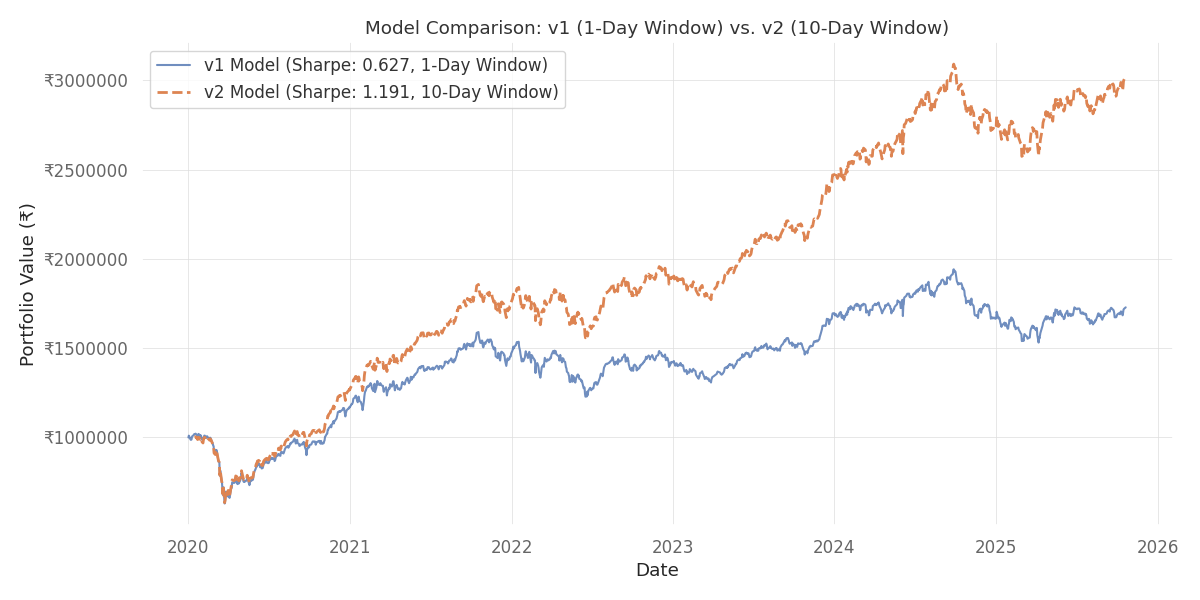

✅ Plot displayed from PNG file.


In [32]:
# ===============================
# CELL 8: RE-PLOT AND DISPLAY PNG
# ===============================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import Image, display

print("Re-generating plot and saving to PNG...")

try:
    # --- Check if data exists ---
    if 'v1_results' not in locals() or 'v2_results' not in locals():
        print("Dataframes 'v1_results' or 'v2_results' not found. Re-run Cell 7 first.")
    else:
        # --- Re-calculate labels ---
        v1_daily_returns = v1_results['account_value'].pct_change(1).dropna()
        v1_sharpe = (v1_daily_returns.mean() / v1_daily_returns.std()) * np.sqrt(252)
        v1_label = f"v1 Model (Sharpe: {v1_sharpe:.3f}, 1-Day Window)"

        v2_daily_returns = v2_results['account_value'].pct_change(1).dropna()
        v2_sharpe = (v2_daily_returns.mean() / v2_daily_returns.std()) * np.sqrt(252)
        v2_label = f"v2 Model (Sharpe: {v2_sharpe:.3f}, 10-Day Window)"

        # --- Re-create Plot ---
        plt.figure(figsize=(12, 6))
        plt.plot(v1_results.index, v1_results['account_value'], label=v1_label, alpha=0.8)
        plt.plot(v2_results.index, v2_results['account_value'], label=v2_label, linewidth=2, linestyle='--')
        plt.title('Model Comparison: v1 (1-Day Window) vs. v2 (10-Day Window)')
        plt.xlabel('Date')
        plt.ylabel('Portfolio Value (₹)')
        plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('₹%.0f'))
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # --- Save to PNG ---
        plot_filename = "v1_vs_v2_comparison_plot.png"
        plt.savefig(plot_filename)
        print(f"✅ Plot saved to {plot_filename}")

        # --- Display the PNG ---
        display(Image(filename=plot_filename))
        print("✅ Plot displayed from PNG file.")

except Exception as e:
    print(f"🔥An error occurred while trying to re-plot: {e}")